# Green-First Ensemble Switcher (Separate Notebook)

This notebook implements an upgraded runtime policy switcher that:
1. Learns from lookahead labels over multiple candidate actions.
2. Trains multiple models (RF, ExtraTrees, GradientBoosting, Logistic).
3. Uses ensemble voting at runtime.
4. Applies green-first objective with latency guards.
5. Benchmarks against classic policies with visual outputs and significance checks.

In [1]:
from __future__ import annotations

import copy
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STEP_MINUTES = 5
STEP_HOURS = STEP_MINUTES / 60.0
HORIZON_STEPS = 288

OVERALL_WEIGHTS = {
    "carbon": 0.35,
    "jct": 0.20,
    "tail": 0.25,
    "preempt": 0.10,
    "starvation": 0.10,
}

CANDIDATE_ACTIONS = [1, 2, 3, 4]
ACTION_NAME = {1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
GREEN_ACTION_BONUS = {1: 0.020, 2: 0.000, 3: 0.006, 4: 0.014}

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 110

print("Setup ready. Seed =", SEED)

Setup ready. Seed = 42


In [2]:
def resolve_clean_dataset() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "clean_dataset.csv",
        cwd.parent / "clean_dataset.csv",
        cwd.parent.parent / "clean_dataset.csv",
        Path("clean_dataset.csv").resolve(),
        Path("../clean_dataset.csv").resolve(),
        Path("../../clean_dataset.csv").resolve(),
    ]
    for p in candidates:
        if p.exists():
            return p

    search_roots = [cwd, cwd.parent, cwd.parent.parent]
    for root in search_roots:
        if root.exists():
            hit = next(root.rglob("clean_dataset.csv"), None)
            if hit is not None:
                return hit.resolve()

    raise FileNotFoundError(f"Could not find clean_dataset.csv. Checked roots: {search_roots}")


def load_and_prepare_v1() -> pd.DataFrame:
    path = resolve_clean_dataset()
    df = pd.read_csv(path)
    required = {"job_name", "task_name", "start_time", "duration", "energy", "plan_cpu"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = df.dropna(subset=["start_time", "duration", "energy", "plan_cpu"]).copy()
    df["duration"] = df["duration"].clip(lower=1)
    df["energy"] = df["energy"].clip(lower=1e-6)
    df["plan_cpu"] = df["plan_cpu"].clip(lower=1.0)
    df["power_proxy"] = df["energy"] / df["duration"]
    return df


def create_realworld_like_dataset(df: pd.DataFrame, seed: int = 31415) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = df.copy().reset_index(drop=True)
    n = len(out)

    out["duration"] = out["duration"].astype(float)
    long_mask = rng.random(n) < 0.24
    short_mask = (~long_mask) & (rng.random(n) < 0.18)

    out.loc[long_mask, "duration"] = np.clip(
        out.loc[long_mask, "duration"] * rng.lognormal(mean=0.45, sigma=0.55, size=long_mask.sum()),
        1,
        np.quantile(out["duration"], 0.995) * 6.0,
    )
    out.loc[short_mask, "duration"] = np.clip(
        out.loc[short_mask, "duration"] * rng.uniform(0.35, 0.78, size=short_mask.sum()),
        1,
        None,
    )

    smin = float(out["start_time"].min())
    smax = float(out["start_time"].max())
    span = max(1.0, smax - smin)
    burst_centers = np.array([smin + 0.20 * span, smin + 0.52 * span, smin + 0.80 * span])
    burst_mask = rng.random(n) < 0.32
    selected_centers = rng.choice(burst_centers, size=burst_mask.sum(), p=[0.30, 0.45, 0.25])
    jitter = rng.normal(0.0, 0.03 * span, size=burst_mask.sum())
    out.loc[burst_mask, "start_time"] = np.clip(selected_centers + jitter, smin, smax).astype(int)

    cpu_norm = (out["plan_cpu"] / out["plan_cpu"].max()).clip(lower=0.05).to_numpy()
    dur = out["duration"].astype(float).to_numpy()
    baseline = out["energy"].astype(float).to_numpy()
    nonlinear = (0.012 * (dur ** 1.16)) * (1.0 + 0.35 * cpu_norm)
    burst_factor = np.ones(n, dtype=float)
    burst_factor[burst_mask] = rng.uniform(1.03, 1.20, size=burst_mask.sum())
    noise_factor = rng.normal(1.0, 0.07, size=n)
    out["energy"] = np.clip((0.35 * baseline + 0.65 * nonlinear) * burst_factor * noise_factor, 1e-6, None)

    miss_mask = rng.random(n) < 0.02
    out.loc[miss_mask, "energy"] = np.nan
    out["energy"] = out["energy"].interpolate(limit_direction="both")

    retry_mask = rng.random(n) < 0.06
    retries = out.loc[retry_mask].copy()
    if len(retries) > 0:
        retries["task_name"] = retries["task_name"].astype(str) + "_retry"
        retries["start_time"] = retries["start_time"].astype(float) + rng.integers(8, 160, size=len(retries))
        retries["duration"] = np.clip(retries["duration"] * rng.uniform(1.15, 1.85, size=len(retries)), 1, None)
        retries["energy"] = np.clip(retries["energy"] * rng.uniform(1.10, 1.40, size=len(retries)), 1e-6, None)
        out = pd.concat([out, retries], ignore_index=True)

    out["duration"] = out["duration"].round().clip(lower=1).astype(int)
    out["plan_cpu"] = out["plan_cpu"].round(2)
    out["energy"] = out["energy"].clip(lower=1e-6)
    out["power_proxy"] = out["energy"] / out["duration"].clip(lower=1)
    return out.sort_values("start_time").reset_index(drop=True)


v1_df = load_and_prepare_v1()
save_dir = Path("../data")
save_dir.mkdir(parents=True, exist_ok=True)
v2_path = save_dir / "clean_dataset_realworld_v2.csv"
if v2_path.exists():
    v2_df = pd.read_csv(v2_path)
    if "power_proxy" not in v2_df.columns:
        v2_df["power_proxy"] = v2_df["energy"] / v2_df["duration"].clip(lower=1)
else:
    v2_df = create_realworld_like_dataset(v1_df)
    v2_df.to_csv(v2_path, index=False)

print(f"v1 rows={len(v1_df):,} | v2 rows={len(v2_df):,}")
display(v1_df[["duration", "energy", "power_proxy"]].describe().round(3))
display(v2_df[["duration", "energy", "power_proxy"]].describe().round(3))

v1 rows=46,533 | v2 rows=49,314


,duration,energy,power_proxy
count,46533.000,46533.000,46533.000
mean,59.846,4.353,0.084
std,129.145,11.869,0.063
min,1.000,0.020,0.005
25%,3.000,0.200,0.050
50%,9.000,0.600,0.100
75%,43.000,2.940,0.100
max,985.000,566.300,0.700


,duration,energy,power_proxy
count,49314.000,49314.000,49314.000
mean,70.093,3.064,0.053
std,184.773,7.935,0.272
min,1.000,0.015,0.000
25%,3.000,0.125,0.029
50%,10.000,0.382,0.041
75%,46.000,2.018,0.050
max,6477.000,231.825,34.579


In [3]:
@dataclass
class Job:
    job_id: int
    submit_step: int
    duration_steps: int
    power_kw: float


def make_workload_from_dataset(congestion: str, horizon_steps: int, rng: np.random.Generator, df: pd.DataFrame) -> list[Job]:
    jobs_per_regime = {"light": 90, "moderate": 160, "high": 250}
    n = jobs_per_regime[congestion]
    sampled = df.sample(n=n, replace=True, random_state=int(rng.integers(1, 1_000_000))).copy()

    smin, smax = float(df["start_time"].min()), float(df["start_time"].max())
    denom = max(1.0, smax - smin)
    sampled["submit_step"] = ((sampled["start_time"] - smin) / denom * (horizon_steps - 1)).round().astype(int)
    sampled["duration_steps"] = np.clip((sampled["duration"] / STEP_MINUTES).round().astype(int), 3, 120)

    q1 = sampled["power_proxy"].quantile(0.33)
    q2 = sampled["power_proxy"].quantile(0.66)

    def to_band(v: float) -> float:
        if v <= q1:
            return 1.2
        if v <= q2:
            return 2.0
        return 3.2

    sampled["power_kw"] = sampled["power_proxy"].apply(to_band)
    return [Job(i, int(r.submit_step), int(r.duration_steps), float(r.power_kw)) for i, r in enumerate(sampled.itertuples(index=False))]


def make_carbon_curve(horizon_steps: int, noise_pct: float, rng: np.random.Generator) -> np.ndarray:
    t = np.arange(horizon_steps)
    base = 260 + 120 * np.sin((2 * np.pi * t / horizon_steps) - (np.pi / 2))
    noise = rng.normal(0.0, (noise_pct / 100.0) * base)
    return np.clip(base + noise, 80, 650).astype(float)


def make_carbon_curve_stress(horizon_steps: int, rng: np.random.Generator, noise_pct: float = 10.0) -> np.ndarray:
    curve = make_carbon_curve(horizon_steps, noise_pct, rng).copy()
    n_spikes = max(1, int(0.03 * horizon_steps))
    n_dips = max(1, int(0.02 * horizon_steps))
    spike_idx = rng.choice(np.arange(horizon_steps), size=n_spikes, replace=False)
    dip_idx = rng.choice(np.arange(horizon_steps), size=n_dips, replace=False)
    curve[spike_idx] += rng.uniform(80, 180, size=len(spike_idx))
    curve[dip_idx] -= rng.uniform(40, 100, size=len(dip_idx))
    return np.clip(curve, 80, 650)


def apply_workload_shocks(jobs: list[Job], rng: np.random.Generator, horizon_steps: int) -> list[Job]:
    shocked = []
    if not jobs:
        return jobs

    burst_center = int(rng.integers(int(0.25 * horizon_steps), int(0.75 * horizon_steps)))
    burst_half_window = 12
    for j in jobs:
        submit_step, duration_steps, power_kw = j.submit_step, j.duration_steps, j.power_kw
        if rng.random() < 0.30:
            submit_step = int(np.clip(rng.integers(burst_center - burst_half_window, burst_center + burst_half_window + 1), 0, horizon_steps - 1))
        if rng.random() < 0.12:
            duration_steps = int(np.clip(duration_steps * rng.uniform(1.4, 2.8), 3, 140))
        if rng.random() < 0.20:
            power_kw = float(np.clip(power_kw * rng.uniform(0.9, 1.25), 1.0, 4.0))
        shocked.append(Job(j.job_id, submit_step, duration_steps, power_kw))
    return shocked


class SimpleClusterEnv:
    def __init__(self, jobs: list[Job], carbon_curve: np.ndarray, capacity: int = 8, reward_weights: Optional[Dict[str, float]] = None):
        self.jobs = {j.job_id: j for j in jobs}
        self.job_order = sorted(jobs, key=lambda x: x.submit_step)
        self.curve = carbon_curve
        self.capacity = capacity
        self.max_step = len(carbon_curve)
        self.median_ci = float(np.median(carbon_curve))
        self.weights = reward_weights or OVERALL_WEIGHTS
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.arrival_ptr = 0
        self.waiting = set()
        self.running = set()
        self.remaining = {jid: self.jobs[jid].duration_steps for jid in self.jobs}
        self.submit = {jid: self.jobs[jid].submit_step for jid in self.jobs}
        self.finish = {}
        self.prev_running = set()

        self.total_carbon_kg = 0.0
        self.total_preemptions = 0
        self.total_wait_steps = 0
        self.total_starvation_penalty = 0.0
        self.done = False
        return self._state()

    def _add_arrivals(self):
        while self.arrival_ptr < len(self.job_order) and self.job_order[self.arrival_ptr].submit_step <= self.step_idx:
            jid = self.job_order[self.arrival_ptr].job_id
            if jid not in self.finish:
                self.waiting.add(jid)
            self.arrival_ptr += 1

    def _active_jobs(self):
        return [jid for jid in self.jobs if jid not in self.finish and self.submit[jid] <= self.step_idx]

    def _state(self):
        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        ci_norm = (ci - 80) / (650 - 80)
        queue_len = len(self.waiting)
        run_len = len(self.running)
        util = run_len / max(1, self.capacity)
        load = min(queue_len / (2 * max(1, self.capacity)), 1.0)

        if self.waiting:
            ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            p90_wait = float(np.percentile(ages, 90)) / 96.0
        else:
            p90_wait = 0.0

        active = self._active_jobs()
        long_ratio = float(np.mean([1.0 if self.remaining[j] >= 24 else 0.0 for j in active])) if active else 0.0
        return np.array([ci_norm, load, util, min(1.0, p90_wait), long_ratio], dtype=np.float32)

    def _policy_rank(self, policy_name: str):
        active = self._active_jobs()
        ci_now = self.curve[min(self.step_idx, self.max_step - 1)]

        if policy_name == "fcfs":
            ranked = sorted(active, key=lambda jid: (self.submit[jid], jid))
        elif policy_name == "carbon":
            if ci_now > self.median_ci:
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (-self.jobs[jid].power_kw, self.submit[jid]))
        elif policy_name == "srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        elif policy_name == "aged_srtf":
            ranked = sorted(active, key=lambda jid: (self.remaining[jid] - 0.15 * max(0, self.step_idx - self.submit[jid]), self.submit[jid]))
        elif policy_name == "carbon_guarded_short":
            if ci_now >= float(np.quantile(self.curve, 0.85)):
                ranked = sorted(active, key=lambda jid: (self.jobs[jid].power_kw, self.submit[jid]))
            else:
                ranked = sorted(active, key=lambda jid: (self.remaining[jid], self.submit[jid]))
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        return ranked[: self.capacity]

    def step(self, action_idx: int):
        self._add_arrivals()
        action_map = {0: "fcfs", 1: "carbon", 2: "srtf", 3: "aged_srtf", 4: "carbon_guarded_short"}
        selected = set(self._policy_rank(action_map[action_idx]))

        preemptions = len(self.prev_running - selected)
        self.total_preemptions += preemptions

        for jid in self._active_jobs():
            if jid in selected:
                self.running.add(jid)
                self.waiting.discard(jid)
            else:
                self.running.discard(jid)
                self.waiting.add(jid)

        ci = self.curve[min(self.step_idx, self.max_step - 1)]
        step_carbon_kg = 0.0
        finished_now = []

        for jid in list(self.running):
            self.remaining[jid] -= 1
            step_carbon_kg += (self.jobs[jid].power_kw * ci * STEP_HOURS) / 1000.0
            if self.remaining[jid] <= 0:
                finished_now.append(jid)

        for jid in finished_now:
            self.finish[jid] = self.step_idx
            self.running.discard(jid)
            self.waiting.discard(jid)

        self.total_wait_steps += len(self.waiting)
        self.total_carbon_kg += step_carbon_kg

        if self.waiting:
            wait_ages = [max(0, self.step_idx - self.submit[jid] + 1) for jid in self.waiting]
            tail_wait = float(np.percentile(wait_ages, 90))
            starvation_ratio = float(np.mean([1.0 if w >= 18 else 0.0 for w in wait_ages]))
        else:
            tail_wait = 0.0
            starvation_ratio = 0.0

        self.total_starvation_penalty += starvation_ratio

        cost = (
            self.weights.get("carbon", 0.0) * step_carbon_kg
            + self.weights.get("jct", 0.0) * (len(self.waiting) + 0.25 * len(self.running))
            + self.weights.get("tail", 0.0) * tail_wait
            + self.weights.get("preempt", 0.0) * (preemptions / max(1, self.capacity))
            + self.weights.get("starvation", 0.0) * starvation_ratio
        )
        reward = -cost

        self.prev_running = set(self.running)
        self.step_idx += 1

        no_future_arrivals = self.arrival_ptr >= len(self.job_order)
        no_active_jobs = len(self.waiting) == 0 and len(self.running) == 0
        self.done = (self.step_idx >= self.max_step) or (no_future_arrivals and no_active_jobs)
        return self._state(), reward, self.done, {}

    def metrics(self):
        completed_jcts = []
        for jid, finish_step in self.finish.items():
            jct = max(1, finish_step - self.submit[jid] + 1)
            completed_jcts.append(jct * STEP_HOURS)

        avg_jct_h = float(np.mean(completed_jcts)) if completed_jcts else np.nan
        tail_jct_h = float(np.percentile(completed_jcts, 95)) if completed_jcts else np.nan
        return {
            "jobs_total": len(self.jobs),
            "jobs_completed": len(self.finish),
            "carbon_kg": self.total_carbon_kg,
            "avg_jct_h": avg_jct_h,
            "tail_jct_h": tail_jct_h,
            "preemptions": self.total_preemptions,
            "avg_wait_h": (self.total_wait_steps * STEP_HOURS) / max(1, len(self.jobs)),
            "starvation_penalty": self.total_starvation_penalty / max(1, self.max_step),
        }


def normalize_metric_by_scenario(df: pd.DataFrame, metric: str, group_cols: list[str]) -> pd.Series:
    gmin = df.groupby(group_cols)[metric].transform("min")
    gmax = df.groupby(group_cols)[metric].transform("max")
    return np.where((gmax - gmin) > 1e-12, (df[metric] - gmin) / (gmax - gmin), 0.0)


def compute_overall_score_robust(detail: pd.DataFrame, weights: Dict[str, float]) -> pd.DataFrame:
    out = detail.copy()
    out["starvation_penalty"] = out["starvation_penalty"].fillna(out["avg_wait_h"].fillna(0.0))
    out["carbon_per_completed_job"] = out["carbon_kg"] / out["jobs_completed"].clip(lower=1)
    out["preempt_per_completed_job"] = out["preemptions"] / out["jobs_completed"].clip(lower=1)

    scenario_cols = ["seed", "noise_pct", "congestion", "capacity", "dataset_track"]
    out["n_carbon"] = normalize_metric_by_scenario(out, "carbon_per_completed_job", scenario_cols)
    out["n_avg_jct"] = normalize_metric_by_scenario(out, "avg_jct_h", scenario_cols)
    out["n_tail_jct"] = normalize_metric_by_scenario(out, "tail_jct_h", scenario_cols)
    out["n_preempt"] = normalize_metric_by_scenario(out, "preempt_per_completed_job", scenario_cols)
    out["n_starvation"] = normalize_metric_by_scenario(out, "starvation_penalty", scenario_cols)

    out["overall_score"] = (
        weights["carbon"] * out["n_carbon"]
        + weights["jct"] * out["n_avg_jct"]
        + weights["tail"] * out["n_tail_jct"]
        + weights["preempt"] * out["n_preempt"]
        + weights["starvation"] * out["n_starvation"]
    )
    return out


def bootstrap_mean_diff_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 2000, seed: int = 42):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    obs = float(np.mean(a) - np.mean(b))
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        sa = rng.choice(a, size=len(a), replace=True)
        sb = rng.choice(b, size=len(b), replace=True)
        diffs[i] = np.mean(sa) - np.mean(sb)
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    p_two = 2.0 * min(np.mean(diffs >= 0.0), np.mean(diffs <= 0.0))
    return obs, float(lo), float(hi), float(p_two)


print("Simulator and scoring helpers ready.")

Simulator and scoring helpers ready.


In [4]:
def lookahead_return(env: SimpleClusterEnv, first_action: int, horizon: int = 6, gamma: float = 0.97) -> float:
    e = copy.deepcopy(env)
    total = 0.0
    disc = 1.0
    done = False
    for t in range(horizon):
        action = first_action if t == 0 else 2
        _, reward, done, _ = e.step(action)
        total += disc * reward
        disc *= gamma
        if done:
            break
    return total


def build_ml_training_data(
    df: pd.DataFrame,
    episodes: int = 18,
    sample_prob: float = 0.55,
    lookahead: int = 6,
    dirty_quantile: float = 0.85,
    seed_base: int = 300_000,
):
    X, y = [], []
    for ep in tqdm(range(episodes), desc=f"Build labels ({seed_base})", unit="ep"):
        rng = np.random.default_rng(seed_base + ep)
        congestion = str(rng.choice(["moderate", "high"], p=[0.35, 0.65]))
        noise = float(rng.choice([10.0, 15.0, 20.0, 25.0], p=[0.20, 0.30, 0.35, 0.15]))
        capacity = int(rng.choice([6, 8], p=[0.75, 0.25]))

        jobs = make_workload_from_dataset(congestion, HORIZON_STEPS, rng, df)
        jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
        curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise)
        env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)

        state = env.reset()
        done = False
        dirty_threshold = float(np.quantile(env.curve, dirty_quantile))

        while not done:
            if rng.random() < sample_prob:
                ci_idx = min(env.step_idx, env.max_step - 1)
                ci_now = float(env.curve[ci_idx])
                ci_prev = float(env.curve[max(0, ci_idx - 1)])
                ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
                ci_slope = (ci_now - ci_prev) / 200.0

                feat = [
                    float(state[0]),
                    float(state[1]),
                    float(state[2]),
                    float(state[3]),
                    float(state[4]),
                    ci_dirty,
                    float(ci_slope),
                    float(state[1] * state[3]),
                    float(state[2] * state[1]),
                ]

                scores = {}
                for a in CANDIDATE_ACTIONS:
                    s = lookahead_return(env, first_action=a, horizon=lookahead, gamma=0.97)
                    s += GREEN_ACTION_BONUS[a]
                    if float(state[3]) >= 0.72 and a in (1, 4):
                        s -= 0.035
                    scores[a] = s

                best_action = max(scores, key=scores.get)
                X.append(feat)
                y.append(best_action)

            behavior_action = 2 if rng.random() < 0.80 else int(rng.choice([1, 3, 4]))
            state, _, done, _ = env.step(behavior_action)

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int32)
    if len(X) == 0:
        raise RuntimeError("No training samples produced")
    return X, y


def train_model_bundle(X: np.ndarray, y: np.ndarray):
    models = {
        "rf": RandomForestClassifier(
            n_estimators=240, max_depth=10, min_samples_leaf=8, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1
        ),
        "et": ExtraTreesClassifier(
            n_estimators=320, max_depth=12, min_samples_leaf=6, class_weight="balanced", random_state=SEED, n_jobs=-1
        ),
        "gb": GradientBoostingClassifier(random_state=SEED),
        "lr": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1400, random_state=SEED)),
    }

    stats = []
    for name, model in models.items():
        model.fit(X, y)
        if hasattr(model, "set_params") and hasattr(model, "n_jobs"):
            model.set_params(n_jobs=1)
        acc = float((model.predict(X) == y).mean())
        stats.append({"model": name, "train_acc": acc})

    weights = {"rf": 0.38, "et": 0.30, "gb": 0.20, "lr": 0.12}
    return models, weights, pd.DataFrame(stats)


def train_track_bundle(df: pd.DataFrame, track_name: str, episodes: int, seed_base: int):
    X, y = build_ml_training_data(df=df, episodes=episodes, seed_base=seed_base)
    models, weights, stats_df = train_model_bundle(X, y)
    label_counts = pd.Series(y).value_counts().sort_index().rename(index=ACTION_NAME)
    print(f"{track_name}: samples={len(X):,}")
    display(stats_df.round(4))
    display(label_counts.to_frame("count"))
    return {"models": models, "weights": weights, "label_counts": label_counts, "stats": stats_df}


bundle_v1 = train_track_bundle(v1_df, "v1_clean", episodes=16, seed_base=310_000)
bundle_v2 = train_track_bundle(v2_df, "v2_realworld", episodes=20, seed_base=340_000)

Build labels (310000):   0%|          | 0/16 [00:00<?, ?ep/s]

Build labels (310000): 100%|██████████| 16/16 [00:56<00:00,  3.53s/ep]


v1_clean: samples=2,511


,model,train_acc
0,rf,0.7726
1,et,0.6404
2,gb,0.9036
3,lr,0.7690


,count
carbon,1949
srtf,21
aged_srtf,391
carbon_guarded_short,150


Build labels (340000): 100%|██████████| 20/20 [01:12<00:00,  3.62s/ep]


v2_realworld: samples=3,168


,model,train_acc
0,rf,0.7150
1,et,0.5887
2,gb,0.8406
3,lr,0.7241


,count
carbon,2153
srtf,110
aged_srtf,682
carbon_guarded_short,223


Tune ensemble: 100%|██████████| 15/15 [04:46<00:00, 19.08s/trial]

Best tuned ensemble cfg: {'hard_wait_guard': 0.6684162355721235, 'soft_wait_guard': 0.45121510135173304, 'green_weight': 0.023628127362378498, 'soft_penalty_carbon': 0.06666915986091596, 'soft_penalty_carbon_guarded': 0.02141692836501844, 'bonus_scale': 0.944106058861461, 'model_weights': {'rf': 0.5891405400555862, 'et': 0.2065810881062399, 'gb': 0.1751340016778889, 'lr': 0.02914437016028491}, 'green_bonus': {1: 0.018882121177229223, 2: 0.0, 3: 0.005664636353168767, 4: 0.013217484824060455}}


,trial,objective,score_gap_vs_srtf,carbon_gain_ratio,hard_wait_guard,soft_wait_guard,green_weight,soft_penalty_carbon,soft_penalty_carbon_guarded,bonus_scale,w_rf,w_et,w_gb,w_lr
0,14,-0.10010,-0.1,0.00196,0.66842,0.45122,0.02363,0.06667,0.02142,0.94411,0.58914,0.20658,0.17513,0.02914
1,1,0.09997,0.1,0.00058,0.70827,0.62422,0.20002,0.03665,0.06663,0.60970,0.33991,0.45632,0.15020,0.05356
2,3,0.09997,0.1,0.00052,0.81696,0.41097,0.22582,0.06625,0.02398,1.24229,0.59668,0.20883,0.05750,0.13699
3,11,0.09997,0.1,0.00052,0.79057,0.73778,0.21576,0.12169,0.08958,0.72495,0.47495,0.28990,0.18138,0.05377
4,5,0.09999,0.1,0.00016,0.75018,0.65731,0.23419,0.02482,0.03686,0.86788,0.30954,0.48058,0.13079,0.07909
5,6,0.80005,0.8,-0.00093,0.68633,0.51821,0.10040,0.11292,0.04073,0.77467,0.32980,0.15942,0.32006,0.19072
6,10,0.80016,0.8,-0.00311,0.63192,0.46695,0.13043,0.06341,0.02256,1.11356,0.37047,0.33151,0.06325,0.23477
7,0,0.80020,0.8,-0.00396,0.68293,0.60309,0.05859,0.02275,0.09580,0.76136,0.50995,0.16319,0.22318,0.10368
8,2,0.80020,0.8,-0.00401,0.67310,0.59903,0.18691,0.10874,0.03218,0.71308,0.32736,0.37508,0.13575,0.16181
9,7,0.80022,0.8,-0.00441,0.79038,0.61549,0.08646,0.06703,0.01328,1.34948,0.30016,0.43177,0.10173,0.16634


Eval v2_realworld: 100%|██████████| 80/80 [07:05<00:00,  5.31s/run]


,dataset_track,policy,noise_pct,congestion,capacity,n,overall_score_mean,overall_score_std,carbon_per_completed_job_mean,avg_jct_mean,tail_jct_mean,share_carbon_mean,share_srtf_mean,overall_score_ci95
6,v1_clean,carbon_guarded_short,20.0,high,6,4,0.3804,0.0204,0.2620,1.6889,6.9760,0.0000,0.0000,0.0200
18,v1_clean,srtf,20.0,high,6,4,0.4385,0.0128,0.2736,1.1758,5.4677,0.0000,1.0000,0.0126
2,v1_clean,aged_srtf,20.0,high,6,4,0.5002,0.0641,0.2742,1.3056,6.3344,0.0000,0.0000,0.0628
14,v1_clean,ml_rf_multiclass,20.0,high,6,4,0.6036,0.0672,0.2665,2.2601,8.0302,0.3741,0.2023,0.0658
10,v1_clean,ml_ensemble_green,20.0,high,6,4,0.6039,0.1764,0.2674,2.4625,7.7115,0.3750,0.0295,0.1728
38,v2_realworld,srtf,20.0,high,6,4,0.4373,0.0450,0.3271,1.1713,4.8646,0.0000,1.0000,0.0441
22,v2_realworld,aged_srtf,20.0,high,6,4,0.4577,0.0517,0.3294,1.2448,5.1719,0.0000,0.0000,0.0507
30,v2_realworld,ml_ensemble_green,20.0,high,6,4,0.4778,0.0674,0.3283,1.2723,5.1927,0.3377,0.0686,0.0660
26,v2_realworld,carbon_guarded_short,20.0,high,6,4,0.5790,0.0343,0.3052,1.5367,6.5833,0.0000,0.0000,0.0336
34,v2_realworld,ml_rf_multiclass,20.0,high,6,4,0.6292,0.0708,0.3177,1.5559,6.2500,0.3325,0.0946,0.0693


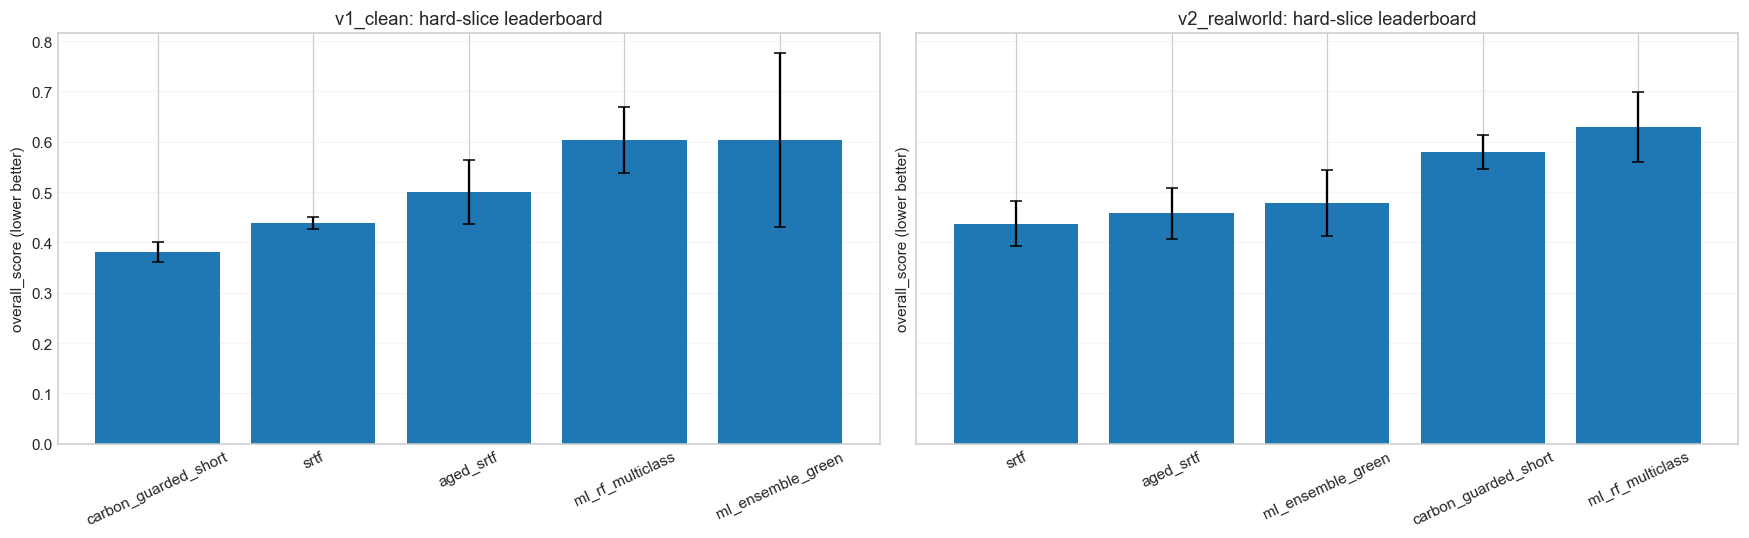

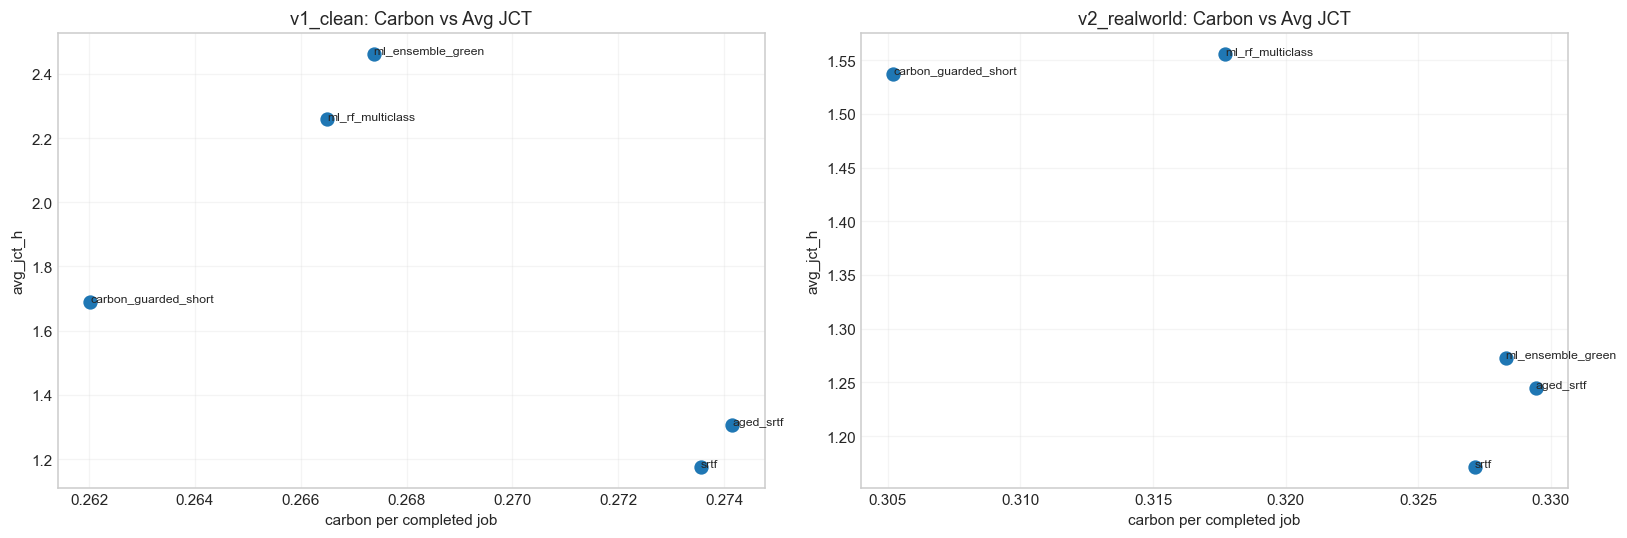

,dataset_track,comparison,mean_diff,ci95_low,ci95_high,p_boot_two_sided,significant_95
0,v1_clean,ml_ensemble_green - srtf,0.165372,0.012709,0.317084,0.0248,True
1,v1_clean,ml_ensemble_green - ml_rf_multiclass,0.000292,-0.157885,0.157797,0.9664,False
2,v2_realworld,ml_ensemble_green - srtf,0.040538,-0.031005,0.106493,0.2696,False
3,v2_realworld,ml_ensemble_green - ml_rf_multiclass,-0.151378,-0.242824,-0.079599,0.0000,True


In [5]:
def predict_action_scores(models: dict, weights: dict, feat: np.ndarray) -> dict[int, float]:
    scores = {a: 0.0 for a in CANDIDATE_ACTIONS}
    total_w = sum(weights.values())

    for name, model in models.items():
        p = model.predict_proba(feat)[0]
        cls = model.classes_
        w = weights[name] / max(total_w, 1e-8)
        for i, a in enumerate(cls):
            scores[int(a)] += w * float(p[i])

    return scores


def choose_action_ensemble_green(
    scores: dict[int, float],
    state: np.ndarray,
    hard_wait_guard: float = 0.72,
    soft_wait_guard: float = 0.56,
    green_weight: float = 0.16,
    green_bonus: Optional[dict[int, float]] = None,
    soft_penalty_carbon: float = 0.08,
    soft_penalty_carbon_guarded: float = 0.04,
) -> int:
    bonus = green_bonus if green_bonus is not None else GREEN_ACTION_BONUS
    adjusted = {a: scores[a] + green_weight * bonus[a] for a in CANDIDATE_ACTIONS}

    if float(state[3]) >= hard_wait_guard:
        allowed = [2, 3]
        return max(allowed, key=lambda a: adjusted[a])

    if float(state[3]) >= soft_wait_guard:
        adjusted[1] -= soft_penalty_carbon
        adjusted[4] -= soft_penalty_carbon_guarded

    return max(CANDIDATE_ACTIONS, key=lambda a: adjusted[a])


def normalize_model_weights(raw: dict[str, float]) -> dict[str, float]:
    total = max(1e-8, float(sum(raw.values())))
    return {k: float(v) / total for k, v in raw.items()}


DEFAULT_ENSEMBLE_CFG = {
    "hard_wait_guard": 0.72,
    "soft_wait_guard": 0.56,
    "green_weight": 0.16,
    "soft_penalty_carbon": 0.08,
    "soft_penalty_carbon_guarded": 0.04,
    "bonus_scale": 1.0,
    "model_weights": {"rf": 0.38, "et": 0.30, "gb": 0.20, "lr": 0.12},
}


def cfg_with_bonus(cfg: dict) -> dict:
    out = dict(cfg)
    out["model_weights"] = normalize_model_weights(out["model_weights"])
    scale = float(out.get("bonus_scale", 1.0))
    out["green_bonus"] = {a: float(GREEN_ACTION_BONUS[a] * scale) for a in CANDIDATE_ACTIONS}
    return out


def sample_ensemble_cfg(rng: np.random.Generator) -> dict:
    hard_wait_guard = float(rng.uniform(0.62, 0.82))
    soft_upper = max(0.40, hard_wait_guard - 0.05)
    soft_wait_guard = float(rng.uniform(0.40, soft_upper))

    raw_w = rng.dirichlet(np.array([4.0, 3.5, 2.2, 1.3]))
    model_weights = normalize_model_weights({"rf": raw_w[0], "et": raw_w[1], "gb": raw_w[2], "lr": raw_w[3]})

    return {
        "hard_wait_guard": hard_wait_guard,
        "soft_wait_guard": soft_wait_guard,
        "green_weight": float(rng.uniform(0.02, 0.24)),
        "soft_penalty_carbon": float(rng.uniform(0.02, 0.14)),
        "soft_penalty_carbon_guarded": float(rng.uniform(0.01, 0.10)),
        "bonus_scale": float(rng.uniform(0.60, 1.45)),
        "model_weights": model_weights,
    }


def run_policy_episode(
    df: pd.DataFrame,
    seed: int,
    noise_pct: float,
    congestion: str,
    capacity: int,
    policy_name: str,
    bundle: Optional[dict] = None,
    ensemble_cfg: Optional[dict] = None,
):
    rng = np.random.default_rng(seed)
    jobs = make_workload_from_dataset(congestion, HORIZON_STEPS, rng, df)
    jobs = apply_workload_shocks(jobs, rng, HORIZON_STEPS)
    curve = make_carbon_curve_stress(HORIZON_STEPS, rng, noise_pct=noise_pct)

    env = SimpleClusterEnv(jobs=jobs, carbon_curve=curve, capacity=capacity, reward_weights=OVERALL_WEIGHTS)
    state = env.reset()
    done = False
    action_counts = {a: 0 for a in CANDIDATE_ACTIONS}
    dirty_threshold = float(np.quantile(env.curve, 0.85))

    fixed_map = {"srtf": 2, "aged_srtf": 3, "carbon_guarded_short": 4}

    while not done:
        if policy_name in fixed_map:
            action = fixed_map[policy_name]
        elif policy_name == "ml_rf_multiclass":
            if bundle is None:
                raise ValueError("bundle required for ml policy")
            model = bundle["models"]["rf"]
            feat = np.asarray([list(state) + [0.0, 0.0, float(state[1] * state[3]), float(state[2] * state[1])]], dtype=np.float32)
            p = model.predict_proba(feat)[0]
            cls = model.classes_
            action = int(cls[int(np.argmax(p))])
            if float(state[3]) >= 0.72 and action in (1, 4):
                action = 2
        elif policy_name == "ml_ensemble_green":
            if bundle is None:
                raise ValueError("bundle required for ml policy")
            cfg = cfg_with_bonus(DEFAULT_ENSEMBLE_CFG if ensemble_cfg is None else ensemble_cfg)
            ci_now = env.curve[min(env.step_idx, env.max_step - 1)]
            ci_prev = env.curve[max(0, env.step_idx - 1)]
            ci_dirty = 1.0 if ci_now >= dirty_threshold else 0.0
            ci_slope = float((ci_now - ci_prev) / 200.0)
            feat = np.asarray([list(state) + [ci_dirty, ci_slope, float(state[1] * state[3]), float(state[2] * state[1])]], dtype=np.float32)

            vote_weights = cfg.get("model_weights", bundle["weights"])
            scores = predict_action_scores(bundle["models"], vote_weights, feat)
            action = choose_action_ensemble_green(
                scores,
                state,
                hard_wait_guard=float(cfg["hard_wait_guard"]),
                soft_wait_guard=float(cfg["soft_wait_guard"]),
                green_weight=float(cfg["green_weight"]),
                green_bonus=cfg["green_bonus"],
                soft_penalty_carbon=float(cfg["soft_penalty_carbon"]),
                soft_penalty_carbon_guarded=float(cfg["soft_penalty_carbon_guarded"]),
            )
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        if action in action_counts:
            action_counts[action] += 1
        state, _, done, _ = env.step(action)

    out = env.metrics()
    out.update(
        {
            "policy": policy_name,
            "seed": seed,
            "noise_pct": noise_pct,
            "congestion": congestion,
            "capacity": capacity,
            "share_carbon": action_counts[1] / max(1, sum(action_counts.values())),
            "share_srtf": action_counts[2] / max(1, sum(action_counts.values())),
            "share_aged_srtf": action_counts[3] / max(1, sum(action_counts.values())),
            "share_carbon_guarded": action_counts[4] / max(1, sum(action_counts.values())),
        }
    )
    return out


def evaluate_track(df: pd.DataFrame, bundle: dict, track_name: str, eval_cfg: dict, ensemble_cfg: Optional[dict] = None) -> pd.DataFrame:
    rows = []
    combos = [(s, n, c, k) for s in eval_cfg["seeds"] for n in eval_cfg["noises"] for c in eval_cfg["congestions"] for k in eval_cfg["capacities"]]
    policies = ["srtf", "aged_srtf", "carbon_guarded_short", "ml_rf_multiclass", "ml_ensemble_green"]

    with tqdm(total=len(combos) * len(policies), desc=f"Eval {track_name}", unit="run") as pbar:
        for seed, noise, cong, cap in combos:
            for p in policies:
                rows.append(run_policy_episode(df, seed, noise, cong, cap, p, bundle=bundle, ensemble_cfg=ensemble_cfg))
                pbar.update(1)

    out = pd.DataFrame(rows)
    out["dataset_track"] = track_name
    return out


def tune_ensemble_on_v2(df: pd.DataFrame, bundle: dict, trials: int = 15, tune_seed: int = 4242):
    rng = np.random.default_rng(tune_seed)
    # Tune on a hard validation slice to prioritize robust real-world behavior.
    tune_cfg = {
        "seeds": [42],
        "noises": [20.0],
        "congestions": ["high"],
        "capacities": [6],
    }
    scenarios = [(s, n, c, k) for s in tune_cfg["seeds"] for n in tune_cfg["noises"] for c in tune_cfg["congestions"] for k in tune_cfg["capacities"]]

    rows = []
    for trial in tqdm(range(trials), desc="Tune ensemble", unit="trial"):
        cfg = sample_ensemble_cfg(rng)

        eval_rows = []
        for seed, noise, congestion, capacity in scenarios:
            eval_rows.append(run_policy_episode(df, seed, noise, congestion, capacity, "srtf", bundle=bundle))
            eval_rows.append(run_policy_episode(df, seed, noise, congestion, capacity, "ml_ensemble_green", bundle=bundle, ensemble_cfg=cfg))

        trial_df = pd.DataFrame(eval_rows)
        trial_df["dataset_track"] = "v2_realworld_tune"
        scored = compute_overall_score_robust(trial_df, OVERALL_WEIGHTS)

        ml_score = float(scored[scored["policy"] == "ml_ensemble_green"]["overall_score"].mean())
        srtf_score = float(scored[scored["policy"] == "srtf"]["overall_score"].mean())

        ml_carbon = float(scored[scored["policy"] == "ml_ensemble_green"]["carbon_per_completed_job"].mean())
        srtf_carbon = float(scored[scored["policy"] == "srtf"]["carbon_per_completed_job"].mean())

        score_gap = ml_score - srtf_score
        carbon_gain = (srtf_carbon - ml_carbon) / max(1e-8, srtf_carbon)
        objective = score_gap - 0.05 * carbon_gain

        rows.append(
            {
                "trial": trial,
                "objective": objective,
                "score_gap_vs_srtf": score_gap,
                "carbon_gain_ratio": carbon_gain,
                "hard_wait_guard": cfg["hard_wait_guard"],
                "soft_wait_guard": cfg["soft_wait_guard"],
                "green_weight": cfg["green_weight"],
                "soft_penalty_carbon": cfg["soft_penalty_carbon"],
                "soft_penalty_carbon_guarded": cfg["soft_penalty_carbon_guarded"],
                "bonus_scale": cfg["bonus_scale"],
                "w_rf": cfg["model_weights"]["rf"],
                "w_et": cfg["model_weights"]["et"],
                "w_gb": cfg["model_weights"]["gb"],
                "w_lr": cfg["model_weights"]["lr"],
            }
        )

    hist = pd.DataFrame(rows).sort_values("objective").reset_index(drop=True)
    best = hist.iloc[0]
    best_cfg = {
        "hard_wait_guard": float(best["hard_wait_guard"]),
        "soft_wait_guard": float(best["soft_wait_guard"]),
        "green_weight": float(best["green_weight"]),
        "soft_penalty_carbon": float(best["soft_penalty_carbon"]),
        "soft_penalty_carbon_guarded": float(best["soft_penalty_carbon_guarded"]),
        "bonus_scale": float(best["bonus_scale"]),
        "model_weights": {
            "rf": float(best["w_rf"]),
            "et": float(best["w_et"]),
            "gb": float(best["w_gb"]),
            "lr": float(best["w_lr"]),
        },
    }
    return best_cfg, hist


best_ensemble_cfg, tuning_history = tune_ensemble_on_v2(v2_df, bundle_v2, trials=15, tune_seed=4310)
print("Best tuned ensemble cfg:", cfg_with_bonus(best_ensemble_cfg))
display(tuning_history.head(10).round(5))


eval_cfg = {
    "seeds": list(range(4)),
    "noises": [10.0, 20.0],
    "congestions": ["moderate", "high"],
    "capacities": [6],
}

detail_v1 = evaluate_track(v1_df, bundle_v1, "v1_clean", eval_cfg, ensemble_cfg=best_ensemble_cfg)
detail_v2 = evaluate_track(v2_df, bundle_v2, "v2_realworld", eval_cfg, ensemble_cfg=best_ensemble_cfg)
detail_all = pd.concat([detail_v1, detail_v2], ignore_index=True)
scored_all = compute_overall_score_robust(detail_all, OVERALL_WEIGHTS)

summary = (
    scored_all.groupby(["dataset_track", "policy", "noise_pct", "congestion", "capacity"], as_index=False)
    .agg(
        n=("seed", "count"),
        overall_score_mean=("overall_score", "mean"),
        overall_score_std=("overall_score", "std"),
        carbon_per_completed_job_mean=("carbon_per_completed_job", "mean"),
        avg_jct_mean=("avg_jct_h", "mean"),
        tail_jct_mean=("tail_jct_h", "mean"),
        share_carbon_mean=("share_carbon", "mean"),
        share_srtf_mean=("share_srtf", "mean"),
    )
)
summary["overall_score_ci95"] = 1.96 * summary["overall_score_std"].fillna(0.0) / np.sqrt(summary["n"].clip(lower=1))

hard = summary[(summary["noise_pct"] == 20.0) & (summary["congestion"] == "high") & (summary["capacity"] == 6)].copy()
display(hard.sort_values(["dataset_track", "overall_score_mean"]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=110, sharey=True)
for i, track in enumerate(["v1_clean", "v2_realworld"]):
    t = hard[hard["dataset_track"] == track].sort_values("overall_score_mean")
    axes[i].bar(t["policy"], t["overall_score_mean"], yerr=t["overall_score_ci95"], capsize=4)
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].set_title(f"{track}: hard-slice leaderboard")
    axes[i].set_ylabel("overall_score (lower better)")
    axes[i].grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=110)
for i, track in enumerate(["v1_clean", "v2_realworld"]):
    t = hard[hard["dataset_track"] == track]
    axes[i].scatter(t["carbon_per_completed_job_mean"], t["avg_jct_mean"], s=70)
    for _, r in t.iterrows():
        axes[i].text(r["carbon_per_completed_job_mean"], r["avg_jct_mean"], r["policy"], fontsize=8)
    axes[i].set_title(f"{track}: Carbon vs Avg JCT")
    axes[i].set_xlabel("carbon per completed job")
    axes[i].set_ylabel("avg_jct_h")
    axes[i].grid(alpha=0.2)
plt.tight_layout()
plt.show()

sig_rows = []
for track in ["v1_clean", "v2_realworld"]:
    t = scored_all[(scored_all["dataset_track"] == track) & (scored_all["noise_pct"] == 20.0) & (scored_all["congestion"] == "high") & (scored_all["capacity"] == 6)]
    a = t[t["policy"] == "ml_ensemble_green"]["overall_score"].values
    b = t[t["policy"] == "srtf"]["overall_score"].values
    c = t[t["policy"] == "ml_rf_multiclass"]["overall_score"].values
    if len(a) and len(b):
        obs, lo, hi, p = bootstrap_mean_diff_ci(a, b, n_boot=2500, seed=SEED)
        sig_rows.append({"dataset_track": track, "comparison": "ml_ensemble_green - srtf", "mean_diff": obs, "ci95_low": lo, "ci95_high": hi, "p_boot_two_sided": p, "significant_95": not (lo <= 0.0 <= hi)})
    if len(a) and len(c):
        obs, lo, hi, p = bootstrap_mean_diff_ci(a, c, n_boot=2500, seed=SEED)
        sig_rows.append({"dataset_track": track, "comparison": "ml_ensemble_green - ml_rf_multiclass", "mean_diff": obs, "ci95_low": lo, "ci95_high": hi, "p_boot_two_sided": p, "significant_95": not (lo <= 0.0 <= hi)})

sig_df = pd.DataFrame(sig_rows)
display(sig_df.round(6))

## How to Read Results

- Lower `overall_score_mean` is better.
- `ml_ensemble_green` should increase green-action share while keeping latency guarded.
- In significance table, negative mean diff means first policy is better (lower score).
- Use exported CSV files in `../data` for report-ready tables.